## 1) Importar bibliotecas

In [1]:
from sklearn.model_selection import train_test_split, learning_curve, LearningCurveDisplay
from sklearn.metrics import PredictionErrorDisplay
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

import polars as pl
import numpy as np

## 2) Ler base de dados

In [2]:
data = pl.read_parquet(
    source = "./diabetes_dataset.parquet"
)

print(data.shape)
data.head(2)

(442, 11)


age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32
59,2,32.099998,101.0,157.0,93.199997,38.0,4.0,4.8598,87.0,151.0
48,1,21.6,87.0,183.0,103.199997,70.0,3.0,3.8918,69.0,75.0


## 3) Treinamento do modelo

### 3.1) Separar por `train_test_split`:

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop("target"),
    data["target"],
    random_state = 1,
    train_size = 0.7,
)

for array in [X_train, X_test, y_train, y_test]:
    print(array.shape)

(309, 10)
(133, 10)
(309,)
(133,)


### 3.2) Treinar modelo:

In [4]:
model = LinearRegression()

model.fit(
    X = X_train,
    y = y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 4) Avaliar modelo:

#### 4.1) `PredictionErrorDisplay`:

Modelos de Regressão Linear podem ser avaliados com uma nova métrica da biblioteca `sklearn` chamado `PredictionErrorDisplay`.

Basicamente, ele avalia se o modelo linear está errando acima ou abaixo do esperado.

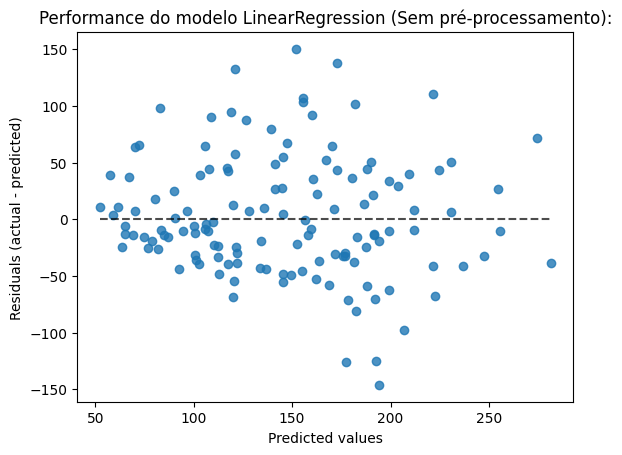

In [5]:
display = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = model.predict(
        X = X_test
    )
)

display.plot()
plt.title("Performance do modelo LinearRegression (Sem pré-processamento):")
plt.show()

### 4.2) `learning_curve`:

Para avaliar a evolução do aprendizado conforme tamanho do dataset de treino, podemos usar o `learning_curve` para ver até onde o modelo começa a operar conforme esperado.

In [6]:
learning_curve_results = learning_curve(
    estimator = model,
    X = data.drop("target"),
    y = data["target"],
    shuffle = True,
    random_state = 1,
    train_sizes = np.linspace(start = 0.01, stop = 1, num = 10)
)

print(learning_curve_results)

(array([  3,  42,  81, 120, 158, 197, 236, 275, 314, 353]), array([[1.        , 1.        , 1.        , 1.        , 1.        ],
       [0.58996701, 0.54713368, 0.58925211, 0.80136454, 0.59528065],
       [0.61176455, 0.53538871, 0.48693758, 0.72679973, 0.59473968],
       [0.58374566, 0.5394789 , 0.45188445, 0.6604774 , 0.54397839],
       [0.58307326, 0.5474385 , 0.48093033, 0.6282264 , 0.54233313],
       [0.57013327, 0.54942769, 0.46827424, 0.58269775, 0.55153072],
       [0.55813026, 0.54968143, 0.49496675, 0.55684119, 0.51357102],
       [0.54488683, 0.5414238 , 0.49911416, 0.53554642, 0.50429827],
       [0.52312434, 0.52036858, 0.52711093, 0.53496414, 0.51722062],
       [0.52428257, 0.51032126, 0.52498507, 0.53166598, 0.50784826]]), array([[-0.86359715, -0.43794715, -0.5343051 , -2.86410666, -1.24913836],
       [-0.164222  ,  0.41668963,  0.34466326,  0.22831261,  0.35517836],
       [ 0.26768851,  0.51532906,  0.38577098,  0.38554698,  0.48975801],
       [ 0.35544521,  0.49

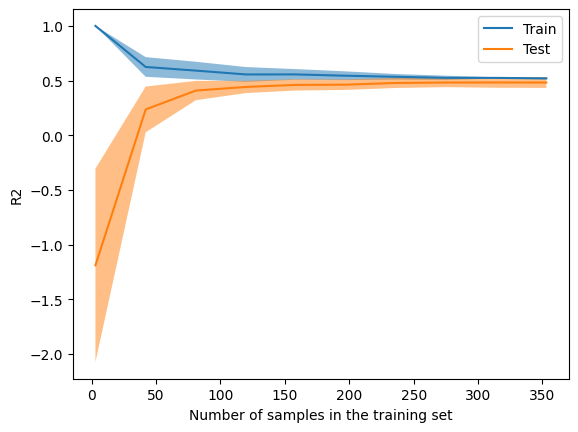

In [7]:
display_learning_curve = LearningCurveDisplay(
    train_sizes = learning_curve_results[0],
    train_scores = learning_curve_results[1],
    test_scores = learning_curve_results[2],
    score_name = "R2"
)

display_learning_curve.plot()

## 5) Criar Pipeline

### 5.1) `ColumnTransformer`

No caso, o método `ColumnTransformer` garante que o `Pipeline` - que é na verdade um sequenciamento de etapas pré-determinadas pelo programador - opere com os dados processados em escala e em formato ideal.

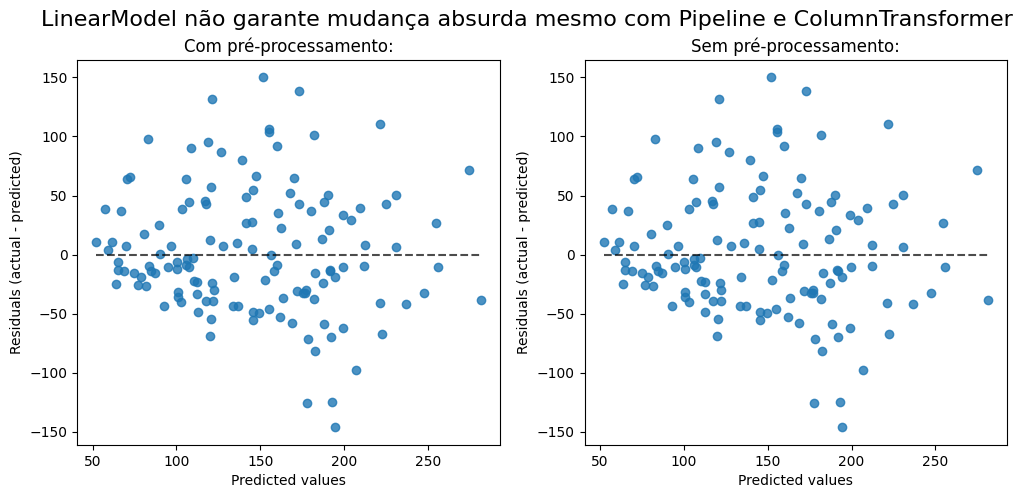

In [8]:
column_transformer = ColumnTransformer(
    transformers = [
        ("OneHotEnc", OneHotEncoder(drop = "if_binary"), ["sex"]),
        ("StandartScaler", StandardScaler(), ["age", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"])
    ]
)

pipeline = Pipeline(
    steps = [
        ("preprocessing", column_transformer),
        ("linear_model", LinearRegression())
    ]
)

pipeline.fit(
    X = X_train, y = y_train
)

fig, axs = plt.subplots(
    ncols = 2,
    figsize = (12, 5)
)

display1 = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = pipeline.predict(
        X = X_test
    )
)

display2 = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = model.predict(
        X = X_test
    )
)

display1.plot(ax = axs[0])
display2.plot(ax = axs[1])

axs[0].set_title("Com pré-processamento:")
axs[1].set_title("Sem pré-processamento:")

plt.suptitle("LinearModel não garante mudança absurda mesmo com Pipeline e ColumnTransformer", fontsize = 16)
plt.show()

In [9]:
pipeline["linear_model"].coef_

array([-22.69046703,  -0.63290146,  28.12590812,  15.89995762,
       -31.56302973,  16.3531121 ,   4.2066783 ,  10.37107075,
        32.52885731,   2.23249873])

In [10]:
model.coef_

array([-4.8333470e-02, -2.2690464e+01,  6.2752104e+00,  1.1902525e+00,
       -8.9102793e-01,  5.3370696e-01,  3.3199707e-01,  8.0301552e+00,
        6.0578606e+01,  1.9105005e-01], dtype=float32)